# CSE754 - PHASE 6
## Data Quality Fix — Aspect-Preserving Crops (removing the black-padding artifact)
Author: Sadia Ruhama — MSc Proposal (CSE 754)

**Why this notebook exists.** Phase 3/5's `crop_one_cell()` padded every non-square bounding box out to a square with **black** pixels before resizing to 224x224. Looking at the sample grid from Phase 5 (`crossbatch_crop_samples.png`), several crops (BT474, SHSY5Y, SkBr3 in particular) are 20-40% black bars. This is a problem for two reasons:

1. DINOv2 was pretrained on natural images with no such artifact — the frozen backbone has never seen large solid-black regions, so LoRA capacity gets spent partly on handling this out-of-distribution artifact instead of cell morphology.
2. If the *amount or position* of black padding correlates with cell type (plausible — different cell lines have systematically different aspect ratios), it becomes a **shortcut feature**: the model could learn "how much black padding" as a proxy for cell type instead of learning real morphological differences. Any accuracy this buys is not the accuracy the proposal is trying to measure.

**The fix.** Instead of padding, we crop a square region **directly from the source image**, centered on the bounding box, with side length `max(w, h) * (1 + 2*pad_frac)`. For the (rare) case where that square would run off the source image edge, we now use **reflect padding** (mirroring nearby real pixel content) instead of a solid black fill — reflect padding is still an artifact, but a much more benign one: it looks like continuous tissue/texture rather than an obvious, uniform, non-biological region.

This notebook regenerates **both** the same-batch data (`data_v2/`, mirroring Phase 3) and the cross-batch data (`data_crossbatch_v2/`, mirroring Phase 5) using the fixed crop function, so Phase 7 can compare training on old vs. new crops.

**Second fix in this notebook:** Phase 5's cross-batch split gave 6 train / 1 val / 1 test wells per cell type — a single held-out well has no statistical power to estimate a generalization gap. Here we shift the split to **~50/25/25** (train/val/test) by well, which for an 8-well cell type gives 4 train / 2 val / 2 test wells — still limited, but at least 2 independent held-out batches instead of 1, and this is stated plainly as a limitation rather than something the notebook pretends to have fully solved (LIVECell simply doesn't have more wells to give).

Recommended runtime: Colab CPU is fine (no model training here, just cropping).

## 1. Setup — installs and Google Drive

In [ ]:
!pip install -q pycocotools requests tqdm pillow

import os, re, json, zipfile
from collections import defaultdict
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
DATA_DIR_V2 = os.path.join(PROJECT_ROOT, 'data_v2')                     # fixed same-batch crops
DATA_DIR_CB_V2 = os.path.join(PROJECT_ROOT, 'data_crossbatch_v2')       # fixed cross-batch crops
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
PHASE6_DIR = os.path.join(OUT_DIR, 'phase6')
RAW_DIR = '/content/livecell_raw'
IMAGES_DIR = os.path.join(RAW_DIR, 'images')
ANN_DIR = os.path.join(RAW_DIR, 'annotations')

for d in [PROJECT_ROOT, DATA_DIR_V2, DATA_DIR_CB_V2, OUT_DIR, PHASE6_DIR, RAW_DIR, IMAGES_DIR, ANN_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Fixed same-batch data ->', DATA_DIR_V2)
print('Fixed cross-batch data ->', DATA_DIR_CB_V2)

Mounted at /content/drive
Project root: /content/drive/MyDrive/cse754
Fixed same-batch data -> /content/drive/MyDrive/cse754/data_v2
Fixed cross-batch data -> /content/drive/MyDrive/cse754/data_crossbatch_v2


## 2. Config

In [ ]:
from dataclasses import dataclass, field
from typing import Tuple

@dataclass
class Phase6Config:
    images_zip_url: str = ('http://livecell-dataset.s3.eu-central-1.amazonaws.com/'
                            'LIVECell_dataset_2021/images.zip')
    ann_urls: dict = field(default_factory=lambda: {
        'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json',
        'val':   'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json',
        'test':  'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json',
    })
    cell_types: Tuple[str, ...] = ('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3')

    crop_size: int = 224
    bbox_padding_frac: float = 0.25

    # ---- same-batch (mirrors Phase 3) ----
    train_crops_per_common_class: int = 400
    val_crops_per_class: int = 80
    test_crops_per_class: int = 100
    rare_cell_type: str = 'BV2'
    train_crops_for_rare_class: int = 15
    max_images_scanned_per_class: int = 60
    max_crops_per_source_image: int = 25

    # ---- cross-batch (mirrors Phase 5, but with more held-out power) ----
    # CHANGED from Phase 5 (0.70/0.15/0.15 -> 6/1/1 wells): shifted to give at
    # least 2 held-out wells per split where the cell type has enough wells,
    # instead of the single-well val/test that had no way to estimate a
    # confidence interval on the generalization gap.
    train_batch_fraction: float = 0.50
    val_batch_fraction: float = 0.25
    max_images_scanned_per_well: int = 20

    seed: int = 42

cfg6 = Phase6Config()
print(cfg6)

Phase6Config(images_zip_url='http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/images.zip', ann_urls={'train': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_train.json', 'val': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_val.json', 'test': 'http://livecell-dataset.s3.eu-central-1.amazonaws.com/LIVECell_dataset_2021/annotations/LIVECell/livecell_coco_test.json'}, cell_types=('A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SkBr3', 'SKOV3'), crop_size=224, bbox_padding_frac=0.25, train_crops_per_common_class=400, val_crops_per_class=80, test_crops_per_class=100, rare_cell_type='BV2', train_crops_for_rare_class=15, max_images_scanned_per_class=60, max_crops_per_source_image=25, train_batch_fraction=0.5, val_batch_fraction=0.25, max_images_scanned_per_well=20, seed=42)


## 3. Download annotations + images.zip
Identical to Phase 3/5 — skips re-download if already present in this Colab session.

In [ ]:
import requests
from tqdm import tqdm

def download_file(url, dest_path, chunk_size=1 << 20):
    if os.path.exists(dest_path) and os.path.getsize(dest_path) > 0:
        print('  already downloaded:', dest_path)
        return
    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=os.path.basename(dest_path)) as pbar:
        for chunk in resp.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk); pbar.update(len(chunk))

ann_paths = {}
for split, url in cfg6.ann_urls.items():
    dest = os.path.join(ANN_DIR, f'livecell_coco_{split}.json')
    download_file(url, dest)
    ann_paths[split] = dest

zip_path = os.path.join(RAW_DIR, 'images.zip')
download_file(cfg6.images_zip_url, zip_path)

if not os.path.exists(os.path.join(IMAGES_DIR, 'livecell_train_val_images')):
    print('Unzipping images.zip...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(RAW_DIR)
else:
    print('Already unzipped.')

livecell_coco_train.json: 100%|██████████| 551M/551M [00:19<00:00, 28.7MB/s]
livecell_coco_val.json: 100%|██████████| 97.3M/97.3M [00:03<00:00, 26.6MB/s]
livecell_coco_test.json: 100%|██████████| 261M/261M [00:08<00:00, 29.7MB/s]
images.zip: 100%|██████████| 1.24G/1.24G [00:34<00:00, 35.8MB/s]


Unzipping images.zip...


## 4. Load COCO annotations, index files on disk, parse cell type + well ID

In [ ]:
from pycocotools.coco import COCO

def cell_type_from_filename(file_name):
    return file_name.split('_Phase_')[0]

_WELL_ID_PATTERN = re.compile(r'^[A-Za-z0-9]+_Phase_([A-Za-z]+\d+_\d+)_\d+d\d+h\d+m_\d+\.tif$')

def well_id_from_filename(file_name):
    m = _WELL_ID_PATTERN.match(file_name)
    return m.group(1) if m else os.path.splitext(file_name)[0]

cocos = {split: COCO(path) for split, path in ann_paths.items()}

print('Indexing extracted image files...')
FILENAME_INDEX = {}
for root, _, files in os.walk(IMAGES_DIR):
    for fn in files:
        if fn.lower().endswith('.tif'):
            FILENAME_INDEX[fn] = os.path.join(root, fn)
print(f'Indexed {len(FILENAME_INDEX):,} .tif files')

def resolve_image_path(file_name):
    return FILENAME_INDEX.get(file_name)

loading annotations into memory...
Done (t=20.37s)
creating index...
index created!
loading annotations into memory...
Done (t=5.14s)
creating index...
index created!
loading annotations into memory...
Done (t=6.33s)
creating index...
index created!
Indexing extracted image files...
Indexed 5,239 .tif files


## 5. Fixed crop function — aspect-preserving, reflect-pad instead of black-pad
Compare `fixed_crop_one_cell` below against Phase 3/5's `crop_one_cell`:
Phase 3/5's version padded to a square canvas filled with `(0,0,0)` (solid black) whenever the
bounding box wasn't already square, which was almost always. The fix below instead **grows the
crop window itself to a square directly on the source image**, so real image content fills the
frame; only when that square would extend past the image boundary does it fall back to
`np.pad(..., mode='reflect')`, which mirrors nearby real pixels rather than inserting an
obviously artificial, uniform region.

In [ ]:
from PIL import Image
import numpy as np

def fixed_crop_one_cell(pil_img: Image.Image, bbox, cfg) -> Image.Image:
    '''Aspect-preserving single-cell crop. Grows the bbox to a square window
    centered on the cell (not padded-after-the-fact), clips to image bounds,
    and only reflect-pads (never black-pads) if the square runs off the edge.'''
    x, y, w, h = bbox
    cx, cy = x + w / 2.0, y + h / 2.0
    side = max(w, h) * (1.0 + 2.0 * cfg.bbox_padding_frac)

    img_arr = np.asarray(pil_img)
    H, W = img_arr.shape[:2]

    half = side / 2.0
    left, right = cx - half, cx + half
    top, bottom = cy - half, cy + half

    # how much we'd need to pad on each side if the square window runs off the image
    pad_left = max(0, int(np.ceil(-left)))
    pad_top = max(0, int(np.ceil(-top)))
    pad_right = max(0, int(np.ceil(right - W)))
    pad_bottom = max(0, int(np.ceil(bottom - H)))

    if pad_left or pad_top or pad_right or pad_bottom:
        img_arr = np.pad(img_arr, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), mode='reflect')
        left, top = left + pad_left, top + pad_top
        right, bottom = right + pad_left, bottom + pad_top

    left, top = max(0, int(round(left))), max(0, int(round(top)))
    right, bottom = int(round(right)), int(round(bottom))
    if right <= left or bottom <= top:
        return None

    crop = Image.fromarray(img_arr[top:bottom, left:right])
    return crop.resize((cfg.crop_size, cfg.crop_size), Image.BILINEAR)


def load_gray_as_rgb(path):
    img = Image.open(path)
    if img.mode != 'RGB':
        img = img.convert('L').convert('RGB')
    return img

## 6. Rebuild same-batch data (`data_v2/`) — mirrors Phase 3's split, fixed crop function only

In [ ]:
def images_by_cell_type(coco):
    grouped = defaultdict(list)
    for img_id in coco.getImgIds():
        info = coco.loadImgs(img_id)[0]
        grouped[cell_type_from_filename(info['file_name'])].append(img_id)
    return grouped

grouped_by_split = {split: images_by_cell_type(coco) for split, coco in cocos.items()}
rng = np.random.RandomState(cfg6.seed)

def build_samebatch_crops(split, coco, grouped, cfg, out_root):
    class_counts = {}
    for cell_type in cfg.cell_types:
        img_ids = list(grouped.get(cell_type, []))
        if not img_ids:
            class_counts[cell_type] = 0
            continue
        if cell_type == cfg.rare_cell_type and split == 'train':
            target = cfg.train_crops_for_rare_class
        elif split == 'train':
            target = cfg.train_crops_per_common_class
        elif split == 'val':
            target = cfg.val_crops_per_class
        else:
            target = cfg.test_crops_per_class

        out_dir = os.path.join(out_root, split, cell_type)
        os.makedirs(out_dir, exist_ok=True)
        rng.shuffle(img_ids)
        img_ids = img_ids[:cfg.max_images_scanned_per_class]

        saved, not_found = 0, 0
        for img_id in img_ids:
            if saved >= target: break
            info = coco.loadImgs(img_id)[0]
            img_path = resolve_image_path(info['file_name'])
            if not img_path: not_found += 1; continue
            pil_img = load_gray_as_rgb(img_path)
            anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
            rng.shuffle(anns)
            n_from_image = 0
            for ann in anns:
                if saved >= target or n_from_image >= cfg.max_crops_per_source_image: break
                crop = fixed_crop_one_cell(pil_img, ann['bbox'], cfg)
                if crop is None: continue
                crop.save(os.path.join(out_dir, f'{cell_type}_{split}_{saved:05d}.png'))
                saved += 1; n_from_image += 1
        class_counts[cell_type] = saved
        print(f'  [{split}] {cell_type:8s}: saved {saved:4d} crops (target {target})'
              + (f' | {not_found} not found on disk' if not_found else ''))
    return class_counts

samebatch_counts = {}
for split, coco in cocos.items():
    print(f'--- {split} ---')
    samebatch_counts[split] = build_samebatch_crops(split, coco, grouped_by_split[split], cfg6, DATA_DIR_V2)

--- train ---
  [train] A172    : saved  400 crops (target 400)
  [train] BT474   : saved  400 crops (target 400)
  [train] BV2     : saved   15 crops (target 15)
  [train] Huh7    : saved  400 crops (target 400)
  [train] MCF7    : saved  400 crops (target 400)
  [train] SHSY5Y  : saved  400 crops (target 400)
  [train] SkBr3   : saved  400 crops (target 400)
  [train] SKOV3   : saved  400 crops (target 400)
--- val ---
  [val] A172    : saved   80 crops (target 80)
  [val] BT474   : saved   80 crops (target 80)
  [val] BV2     : saved   80 crops (target 80)
  [val] Huh7    : saved   80 crops (target 80)
  [val] MCF7    : saved   80 crops (target 80)
  [val] SHSY5Y  : saved   80 crops (target 80)
  [val] SkBr3   : saved   80 crops (target 80)
  [val] SKOV3   : saved   80 crops (target 80)
--- test ---
  [test] A172    : saved  100 crops (target 100)
  [test] BT474   : saved  100 crops (target 100)
  [test] BV2     : saved  100 crops (target 100)
  [test] Huh7    : saved  100 crops (ta

## 7. Rebuild cross-batch data (`data_crossbatch_v2/`) — wider held-out split + fixed crops
Same well-pooling logic as Phase 5, but `train_batch_fraction=0.50` / `val_batch_fraction=0.25`
instead of Phase 5's 0.70/0.15 — for an 8-well cell type this now gives **4 train / 2 val / 2
test wells** instead of 6/1/1, so the held-out generalization-gap estimate has at least 2
independent batches to vary over instead of exactly 1. This is still limited (LIVECell's own
data ceiling), and the notebook says so explicitly in Section 9's summary rather than treating
it as fully solved.

In [ ]:
all_images_by_celltype = defaultdict(dict)
for split, coco in cocos.items():
    for img_id in coco.getImgIds():
        info = coco.loadImgs(img_id)[0]
        fn = info['file_name']
        ctype = cell_type_from_filename(fn)
        if fn not in all_images_by_celltype[ctype]:
            all_images_by_celltype[ctype][fn] = (split, img_id)

well_split_assignment = {}
images_by_split_cb = defaultdict(lambda: defaultdict(list))
cb_rng = np.random.RandomState(cfg6.seed)

for ctype, images in all_images_by_celltype.items():
    wells = sorted({well_id_from_filename(fn) for fn in images})
    cb_rng.shuffle(wells)
    n_wells = len(wells)
    n_train = max(1, int(round(n_wells * cfg6.train_batch_fraction)))
    n_val = max(1, int(round(n_wells * cfg6.val_batch_fraction)))
    n_val = min(n_val, max(0, n_wells - n_train - 1))
    train_wells = set(wells[:n_train])
    val_wells = set(wells[n_train:n_train + n_val])
    test_wells = set(wells[n_train + n_val:])
    well_split_assignment[ctype] = {}
    for w in train_wells: well_split_assignment[ctype][w] = 'train'
    for w in val_wells: well_split_assignment[ctype][w] = 'val'
    for w in test_wells: well_split_assignment[ctype][w] = 'test'
    for fn in images:
        images_by_split_cb[well_split_assignment[ctype][well_id_from_filename(fn)]][ctype].append(fn)
    print(f'{ctype:8s}: {n_wells} wells -> train={len(train_wells)} val={len(val_wells)} test={len(test_wells)}')

file_lookup = {fn: v for ctype, images in all_images_by_celltype.items() for fn, v in images.items()}

def build_crossbatch_crops(split, cfg, out_root):
    class_counts = {}
    for cell_type in cfg.cell_types:
        file_names = images_by_split_cb[split].get(cell_type, [])
        if not file_names:
            class_counts[cell_type] = 0; continue
        if cell_type == cfg.rare_cell_type and split == 'train':
            target = cfg.train_crops_for_rare_class
        elif split == 'train':
            target = cfg.train_crops_per_common_class
        elif split == 'val':
            target = cfg.val_crops_per_class
        else:
            target = cfg.test_crops_per_class

        out_dir = os.path.join(out_root, split, cell_type)
        os.makedirs(out_dir, exist_ok=True)
        by_well = defaultdict(list)
        for fn in file_names: by_well[well_id_from_filename(fn)].append(fn)
        well_ids = list(by_well.keys())
        cb_rng.shuffle(well_ids)

        saved, not_found = 0, 0
        for w in well_ids:
            if saved >= target: break
            fns = by_well[w][:cfg.max_images_scanned_per_well]
            cb_rng.shuffle(fns)
            for fn in fns:
                if saved >= target: break
                coco_split_key, img_id = file_lookup[fn]
                img_path = resolve_image_path(fn)
                if not img_path: not_found += 1; continue
                pil_img = load_gray_as_rgb(img_path)
                anns = cocos[coco_split_key].loadAnns(cocos[coco_split_key].getAnnIds(imgIds=img_id))
                cb_rng.shuffle(anns)
                n_from_image = 0
                for ann in anns:
                    if saved >= target or n_from_image >= cfg.max_crops_per_source_image: break
                    crop = fixed_crop_one_cell(pil_img, ann['bbox'], cfg)
                    if crop is None: continue
                    crop.save(os.path.join(out_dir, f'{cell_type}_{split}_{saved:05d}.png'))
                    saved += 1; n_from_image += 1
        class_counts[cell_type] = saved
        print(f'  [{split}] {cell_type:8s}: saved {saved:4d} crops (target {target}, {len(well_ids)} wells)'
              + (f' | {not_found} not found' if not_found else ''))
    return class_counts

crossbatch_counts = {}
for split in ['train', 'val', 'test']:
    print(f'--- {split} (batch-stratified, fixed crops) ---')
    crossbatch_counts[split] = build_crossbatch_crops(split, cfg6, DATA_DIR_CB_V2)

BT474   : 8 wells -> train=4 val=2 test=2
A172    : 8 wells -> train=4 val=2 test=2
MCF7    : 8 wells -> train=4 val=2 test=2
BV2     : 8 wells -> train=4 val=2 test=2
Huh7    : 6 wells -> train=3 val=2 test=1
SkBr3   : 8 wells -> train=4 val=2 test=2
SKOV3   : 8 wells -> train=4 val=2 test=2
SHSY5Y  : 8 wells -> train=4 val=2 test=2
--- train (batch-stratified, fixed crops) ---
  [train] A172    : saved  400 crops (target 400, 4 wells)
  [train] BT474   : saved  400 crops (target 400, 4 wells)
  [train] BV2     : saved   15 crops (target 15, 4 wells)
  [train] Huh7    : saved  400 crops (target 400, 3 wells)
  [train] MCF7    : saved  400 crops (target 400, 4 wells)
  [train] SHSY5Y  : saved  400 crops (target 400, 4 wells)
  [train] SkBr3   : saved  400 crops (target 400, 4 wells)
  [train] SKOV3   : saved  400 crops (target 400, 4 wells)
--- val (batch-stratified, fixed crops) ---
  [val] A172    : saved   80 crops (target 80, 2 wells)
  [val] BT474   : saved   80 crops (target 80, 

## 8. Sanity checks: class-index mapping, well-leakage check, before/after crop comparison

In [ ]:
train_classes_on_disk = sorted(os.listdir(os.path.join(DATA_DIR_V2, 'train')))
class_to_idx = {c_: i for i, c_ in enumerate(train_classes_on_disk)}
rare_class_idx = class_to_idx[cfg6.rare_cell_type]
print('Class -> index mapping (same-batch and cross-batch use identical class names, so this'
      ' mapping applies to both data_v2/ and data_crossbatch_v2/):')
for c_, i in class_to_idx.items():
    print(f'  {i}: {c_}')
print(f'\n>>> Phase 7 Config: num_classes={len(class_to_idx)}, rare_class_idx={rare_class_idx} ({cfg6.rare_cell_type})')

leak_found = False
for ctype in cfg6.cell_types:
    assignment = well_split_assignment.get(ctype, {})
    tr = {w for w, s in assignment.items() if s == 'train'}
    va = {w for w, s in assignment.items() if s == 'val'}
    te = {w for w, s in assignment.items() if s == 'test'}
    overlap = (tr & va) | (tr & te) | (va & te)
    if overlap:
        leak_found = True
        print(f'  [FAIL] {ctype}: well leakage: {overlap}')
assert not leak_found, 'Well leakage detected -- fix before training.'
print('Well-leakage check passed for data_crossbatch_v2/.')

summary = {
    'class_to_idx': class_to_idx, 'rare_class_idx': rare_class_idx,
    'samebatch_counts': samebatch_counts, 'crossbatch_counts': crossbatch_counts,
    'well_split_assignment': well_split_assignment,
}
with open(os.path.join(PHASE6_DIR, 'phase6_data_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved summary to', os.path.join(PHASE6_DIR, 'phase6_data_summary.json'))

Class -> index mapping (same-batch and cross-batch use identical class names, so this mapping applies to both data_v2/ and data_crossbatch_v2/):
  0: A172
  1: BT474
  2: BV2
  3: Huh7
  4: MCF7
  5: SHSY5Y
  6: SKOV3
  7: SkBr3

>>> Phase 7 Config: num_classes=8, rare_class_idx=2 (BV2)
Well-leakage check passed for data_crossbatch_v2/.
Saved summary to /content/drive/MyDrive/cse754/outputs/phase6/phase6_data_summary.json


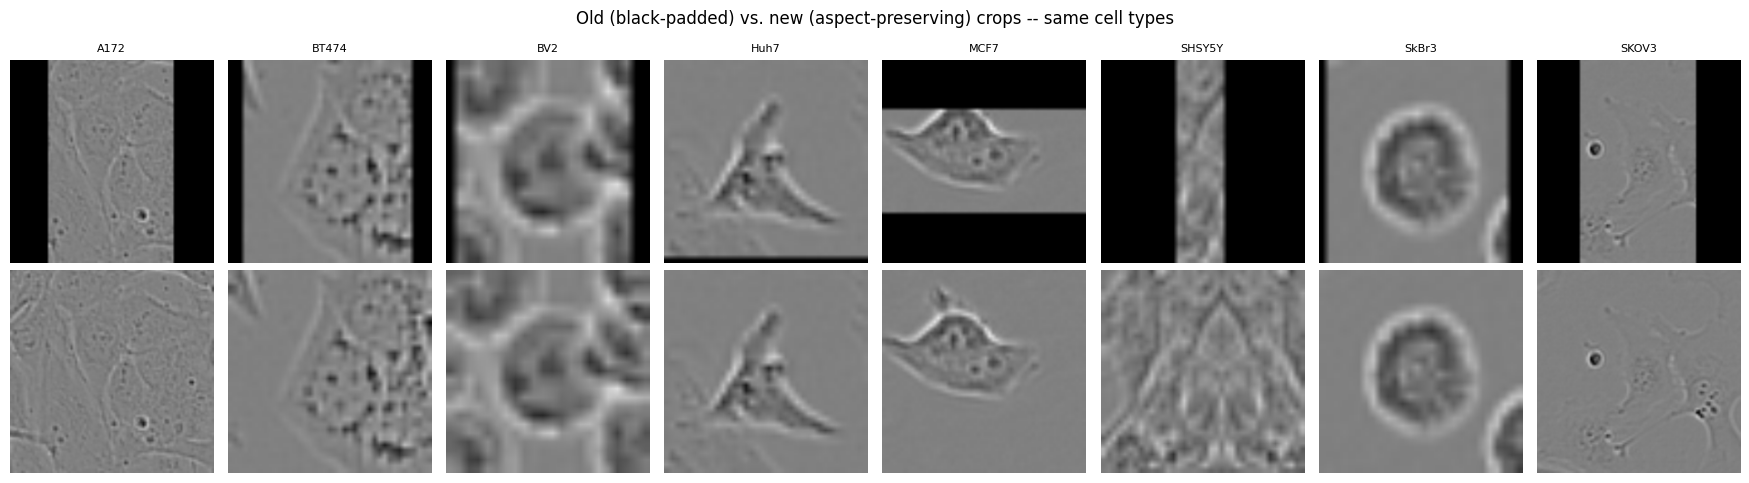

Saved comparison grid to /content/drive/MyDrive/cse754/outputs/phase6/crop_fix_before_after.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, len(cfg6.cell_types), figsize=(2.2 * len(cfg6.cell_types), 5))
for row, (label, folder) in enumerate([('OLD (black-pad)', os.path.join(PROJECT_ROOT, 'data')),
                                        ('NEW (reflect, aspect-preserving)', DATA_DIR_V2)]):
    for col, ctype in enumerate(cfg6.cell_types):
        class_dir = os.path.join(folder, 'train', ctype)
        files = os.listdir(class_dir) if os.path.isdir(class_dir) else []
        ax = axes[row, col]
        if files:
            ax.imshow(Image.open(os.path.join(class_dir, files[0])))
        ax.set_title(ctype if row == 0 else '', fontsize=8)
        ax.axis('off')
    axes[row, 0].set_ylabel(label, fontsize=8)
plt.suptitle('Old (black-padded) vs. new (aspect-preserving) crops -- same cell types')
plt.tight_layout()
plot_path = os.path.join(PHASE6_DIR, 'crop_fix_before_after.png')
plt.savefig(plot_path, dpi=130)
plt.show()
print('Saved comparison grid to', plot_path)

## Notes / next steps
- Run **Phase 7** next, pointed at `data_v2/` (same-batch) and `data_crossbatch_v2/` (cross-batch)
  in turn — it reuses Phase 4 v2's training pipeline (early stopping + weight decay + temperature
  scaling) unchanged, plus the fixed acquisition function.
- If you want a true apples-to-apples "did the crop fix matter" ablation, also re-run Phase 4 v2's
  *unmodified* pipeline on `data_v2/` (old acquisition function, new crops) as a separate log, so
  the crop-fix effect and the acquisition-fix effect can be attributed independently rather than
  conflated into a single before/after number.
- Known remaining limitation, stated plainly for the report: `data_crossbatch_v2/` still has at
  most 2 held-out wells per split for most cell types (LIVECell's data ceiling, not a bug) — a
  95% CI on the generalization gap is not really estimable from n=2; report the gap as a point
  estimate with this caveat, not as a statistically validated claim.